
=== Données nettoyées ===
     milieu                     localite  annee   ipm  taux_pauvrete  \
0  Ensemble  Région de Guelmim-Oued Noun   2024  0.02           4.94   
1  Ensemble  Région de Guelmim-Oued Noun   2014  0.04          10.31   
2     Rural  Région de Guelmim-Oued Noun   2024  0.04          10.27   
3     Rural  Région de Guelmim-Oued Noun   2014  0.09          22.12   
4    Urbain  Région de Guelmim-Oued Noun   2024  0.01           2.79   
5    Urbain  Région de Guelmim-Oued Noun   2014  0.01           4.02   

   intensite  vulnerabilite  
0      35.94           5.29  
1      37.74           9.73  
2      38.16          14.48  
3      40.93          21.83  
4      35.04           1.57  
5      36.03           3.28  

=== Statistiques descriptives ===
                 ipm             taux_pauvrete               intensite         \
                mean   min   max          mean    min    max      mean    min   
milieu   annee                                               

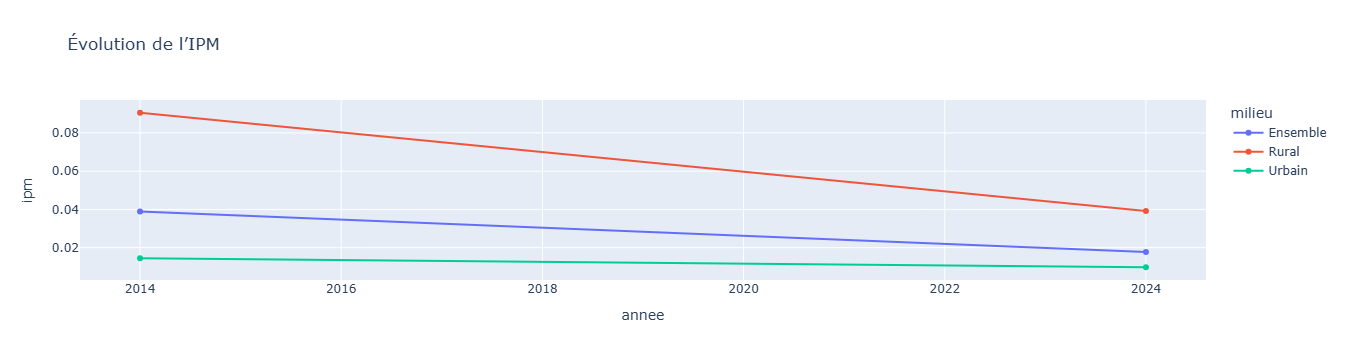

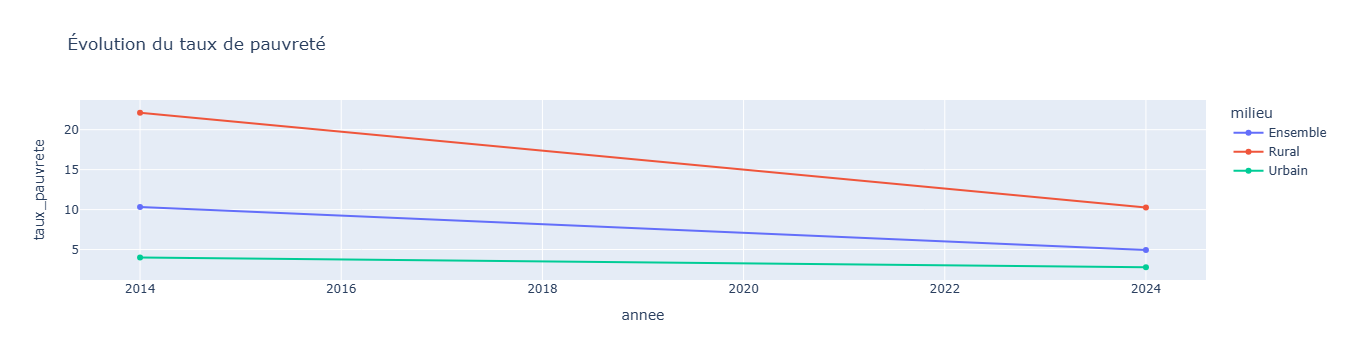

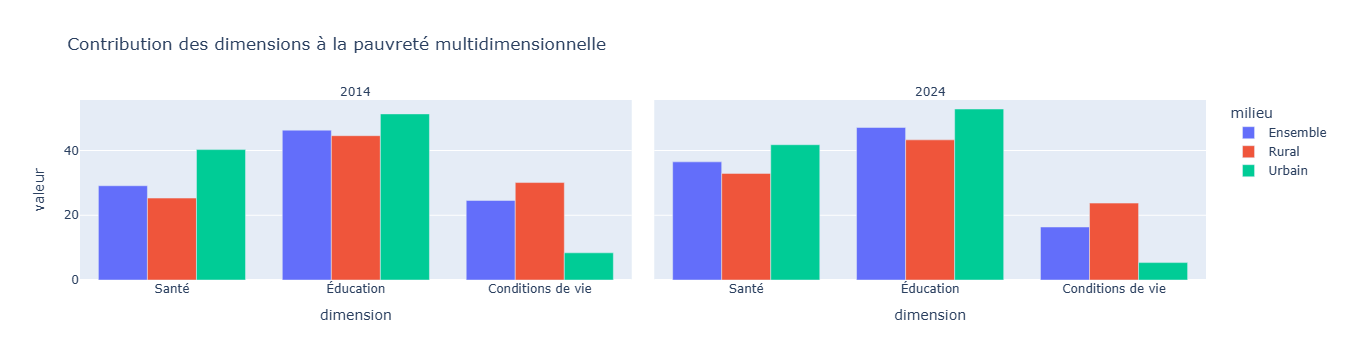


Analyse terminée avec succès.
Fichiers créés :
- donnees_nettoyees.csv
- comparaison_2014_2024.csv
- resume_par_milieu_annee.csv
- evolution_ipm.png
- evolution_taux_pauvrete.png


In [6]:
import pandas as pd
import plotly.express as px

fichiers = {
    "Ensemble": "../data/Ensemble.csv",
    "Rural": "../data/Rural.csv",
    "Urbain": "../data/Urbain.csv"
}
liste_donnees = []

# ==============================
# 2. Lecture, nettoyage et préparation
# ==============================

for milieu, chemin in fichiers.items():

    df = pd.read_csv(
        chemin,
        sep=None,
        engine="python",
        encoding="utf-8-sig",
        header=None
    )

    # Donner des noms fixes aux colonnes
    df.columns = [f"col_{i}" for i in range(len(df.columns))]

    # Supprimer les lignes d’en-tête inutiles si elles existent
    df = df[df["col_4"].astype(str).str.strip().isin(["2014", "2024"])].copy()

    # Renommer les colonnes importantes
    df = df.rename(columns={
        "col_1": "localite",
        "col_2": "code_localite",
        "col_3": "niveau",
        "col_4": "annee",
        "col_5": "ipm",
        "col_6": "taux_pauvrete",
        "col_7": "intensite",
        "col_8": "vulnerabilite",
        "col_9": "privation_mortalite",
        "col_10": "privation_handicap",
        "col_11": "privation_scolarisation",
        "col_12": "privation_annees_scolarite",
        "col_13": "privation_electricite",
        "col_14": "privation_eau",
        "col_15": "privation_assainissement",
        "col_16": "privation_logement",
        "col_17": "privation_cuisson",
        "col_18": "privation_communication",
        "col_29": "contribution_sante",
        "col_30": "contribution_education",
        "col_31": "contribution_conditions_vie"
    })

    # Conversion numérique
    colonnes_numeriques = [
        "annee",
        "code_localite",
        "ipm",
        "taux_pauvrete",
        "intensite",
        "vulnerabilite",
        "privation_mortalite",
        "privation_handicap",
        "privation_scolarisation",
        "privation_annees_scolarite",
        "privation_electricite",
        "privation_eau",
        "privation_assainissement",
        "privation_logement",
        "privation_cuisson",
        "privation_communication",
        "contribution_sante",
        "contribution_education",
        "contribution_conditions_vie"
    ]

    for colonne in colonnes_numeriques:
        if colonne in df.columns:
            df[colonne] = pd.to_numeric(df[colonne], errors="coerce")

    # Supprimer les lignes contenant NaN dans les indicateurs principaux
    df = df.dropna(subset=[
        "ipm",
        "taux_pauvrete",
        "intensite",
        "vulnerabilite"
    ])

    # Ajouter le milieu
    df["milieu"] = milieu

    liste_donnees.append(df)

# ==============================
# 3. Fusion des trois fichiers
# ==============================

donnees = pd.concat(liste_donnees, ignore_index=True)

# ==============================
# 4. Aperçu des données nettoyées
# ==============================

print("\n=== Données nettoyées ===")
print(donnees[[
    "milieu",
    "localite",
    "annee",
    "ipm",
    "taux_pauvrete",
    "intensite",
    "vulnerabilite"
]].round(2))

# ==============================
# 5. Statistiques descriptives
# ==============================

print("\n=== Statistiques descriptives ===")
print(
    donnees.groupby(["milieu", "annee"])[[
    "ipm",
    "taux_pauvrete",
    "intensite",
    "vulnerabilite"
]].agg(["mean", "min", "max"]).round(2)
)

# ==============================
# 6. Comparaison 2014 / 2024
# ==============================

comparaison = donnees.pivot_table(
    index="milieu",
    columns="annee",
    values=[
        "ipm",
        "taux_pauvrete",
        "intensite",
        "vulnerabilite"
    ],
    aggfunc="mean"
)

comparaison.columns = [
    f"{indicateur}_{annee}" for indicateur, annee in comparaison.columns
]

comparaison = comparaison.reset_index()

indicateurs = [
    "ipm",
    "taux_pauvrete",
    "intensite",
    "vulnerabilite"
]

for indicateur in indicateurs:
    col_2014 = f"{indicateur}_2014"
    col_2024 = f"{indicateur}_2024"

    if col_2014 in comparaison.columns and col_2024 in comparaison.columns:
        comparaison[f"{indicateur}_variation"] = (
            comparaison[col_2024] - comparaison[col_2014]
        )

        comparaison[f"{indicateur}_variation_pourcentage"] = (
            comparaison[f"{indicateur}_variation"] /
            comparaison[col_2014] * 100
        )

print("\n=== Comparaison entre 2014 et 2024 ===")
print(comparaison.round(2))

# ==============================
# 7. Analyse des privations
# ==============================

colonnes_privations = [
    "privation_mortalite",
    "privation_handicap",
    "privation_scolarisation",
    "privation_annees_scolarite",
    "privation_electricite",
    "privation_eau",
    "privation_assainissement",
    "privation_logement",
    "privation_cuisson",
    "privation_communication"
]

print("\n=== Moyenne des privations par milieu et par année ===")
print(
    donnees.groupby(["milieu", "annee"])[colonnes_privations].mean().round(2)
)

print("\n=== Les 5 privations les plus importantes en 2024 ===")

donnees_2024 = donnees[donnees["annee"] == 2024]

for milieu in donnees_2024["milieu"].unique():
    moyennes = donnees_2024[
        donnees_2024["milieu"] == milieu
    ][colonnes_privations].mean().round(2)

    print(f"\n{milieu}")
    print(moyennes.sort_values(ascending=False).head(5))

# ==============================
# 8. Analyse des contributions
# ==============================

colonnes_contributions = [
    "contribution_sante",
    "contribution_education",
    "contribution_conditions_vie"
]

print("\n=== Contributions moyennes ===")
print(
    donnees.groupby(["milieu", "annee"])[colonnes_contributions].mean().round(2)
)

# ==============================
# 9. Résumé pour graphiques
# ==============================

resume = donnees.groupby(["milieu", "annee"])[[
    "ipm",
    "taux_pauvrete",
    "intensite",
    "vulnerabilite"
]].mean().reset_index()

contrib = donnees.groupby(["milieu", "annee"])[[
    "contribution_sante",
    "contribution_education",
    "contribution_conditions_vie"
]].mean().reset_index()

contrib_melt = contrib.melt(
    id_vars=["milieu", "annee"],
    var_name="dimension",
    value_name="valeur"
)
# ==============================
# 10. Graphique IPM
# ==============================

fig_ipm = px.line(
    resume,
    x="annee",
    y="ipm",
    color="milieu",
    markers=True,
    title="Évolution de l’IPM",
)

fig_ipm.show()

# ==============================
# 11. Graphique taux de pauvreté
# ==============================

fig_pauvrete = px.line(
    resume,
    x="annee",
    y="taux_pauvrete",
    color="milieu",
    markers=True,
    title="Évolution du taux de pauvreté",
)

fig_pauvrete.show()

# ==============================
# 12. Graphique vulnérabilité
# ==============================

#fig_vulnerabilite = px.line(
#    resume,
 #   x="annee",
  #  y="vulnerabilite",
   # color="milieu",
    # markers=True,
    # title="Évolution de la vulnérabilité",
#)

#fig_vulnerabilite.show()

# ==============================
# 13. Graphique vulnérabilité
# ==============================
contrib_melt["dimension"] = contrib_melt["dimension"].replace({
    "contribution_sante": "Santé",
    "contribution_education": "Éducation",
    "contribution_conditions_vie": "Conditions de vie"
})

fig = px.bar(
    contrib_melt,
    x="dimension",
    y="valeur",
    color="milieu",
    barmode="group",
    facet_col="annee",
    title="Contribution des dimensions à la pauvreté multidimensionnelle"
)
for annotation in fig.layout.annotations:
    annotation.text = (
        annotation.text
        .replace("annee=", "")
        .replace("année=", "")
        .replace("annee = ", "")
        .replace("année = ", "")
       
    )


fig.show()

# ==============================
# 14. Sauvegarde des résultats
# ==============================

#donnees.to_csv(
 #   "donnees_nettoyees.csv",
  #  index=False,
   # encoding="utf-8-sig"
#)

#comparaison.to_csv(
 #   "comparaison_2014_2024.csv",
  #  index=False,
   # encoding="utf-8-sig"
#)

# resume.to_csv(
  #  "resume_par_milieu_annee.csv",
   # index=False,
    # encoding="utf-8-sig"
#)

print("\nAnalyse terminée avec succès.")
print("Fichiers créés :")
print("- donnees_nettoyees.csv")
print("- comparaison_2014_2024.csv")
print("- resume_par_milieu_annee.csv")
print("- evolution_ipm.png")
print("- evolution_taux_pauvrete.png")

df.to_csv(r"../data/outputs/analyse_pauvrete.csv", index=False)